# Pseudomode mapping for heat transfer in spin-boson model with Ohmic bath

## Introduction

This notebook simulates the heat exchange dynamics between a two-level system and bosonic bath using the pseudomode mapping approach of (Pleasance et al). Further details on the simulated model can be found in [pm_ohmic.ipynb](pm_ohmic.ipynb). 

The average heat transferred from bath modes of bandwidth $[\omega-\delta/2,\omega+\delta/2]$ to a two-level system with coupling operator $\sigma_z$ is given by (ref - Gribben et al)
\begin{equation*}
    \Delta Q(\omega,t) = \int^t_0dt'\int^t_0dt''\,\langle\sigma_z(t')\sigma_z(t'')\rangle\int^{\omega + \delta/2}_{\omega-\delta/2}d\omega'\,\omega'F(\omega',t'-t'',\beta),
\end{equation*}
where $\langle\sigma_z(t')\sigma_z(t'')\rangle = {\rm Tr}[e^{iHt'}\sigma_ze^{-iH(t'-t'')}\sigma_ze^{-iHt''}\rho_S\otimes \rho_B]$, and 
\begin{equation*}
    F(\omega,t,\beta) = J(\omega)\Big[\cos(\omega t) - i\coth\Big(\frac{\beta\omega}{2}\Big)\sin(\omega t)\Big],
\end{equation*}
with $J(\omega)$ the bath spectral density, and $\beta = 1/k_BT$ the inverse bath temperature. 

In the following we choose an Ohmic bath spectral density 
\begin{equation*}
    J(\omega) = \alpha\omega e^{-\omega/\omega_c}.
\end{equation*}

In [122]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import matplotlib as mpl
import oqupy as oq

In [123]:
# Parameters (units of TLS energy eps = Del)
alph = 0.25
T = 1.0
w_cut = 1.0

tlist = np.linspace(0, 10, 500)
omlist = np.linspace(-20, 20, 500)

bath = qt.OhmicEnvironment(T=T, alpha=alph, wc=w_cut, s=1)

## Fitting of bath correlation function 

We first extract the PM parameters from the bath correlation function (BCF) and benchmark the reduced system dynamics of the PMME against TEMPO. 

The fitted BCF is of the form 
\begin{equation}
    C^E(t) = 
    \begin{cases}
    -i\sum^N_{l=1}r_le^{-iz_lt} &t\geq0, \\
    i\sum^N_{l=1}r^*_le^{iz^*_l|t|} &t<0,
    \end{cases}
\end{equation}
where $r_l = r^R_l + ir^I_l$ and $z_l = z^R_l - iz^I_l$ ($z^I_l \geq 0$). In parallel, the corresponding power spectrum $\gamma'(\omega) = 2\,{\rm Re}\int^{\infty}_{0}dt\,C^E(t)e^{i\omega t}$ is given as 
\begin{equation*}
    \gamma'(\omega) = 2\sum^N_{l=1}\frac{r^R_l(\omega - z^R_l) + r^I_lz^I_l}{(\omega - z^R_l)^2 + (z^I_l)^2}. 
\end{equation*}

<!-- NB: The "ps" fitting method of QuTIP extracts a real set of fitted parameters $\{\boldsymbol{a}, \boldsymbol{b}, \boldsymbol{c}, \boldsymbol{d}\}$ from the decomposition $C^E(t) = \sum^N_{l=1}(a_l+ib_l)e^{-(c_l + id_l)t}$. 

% See QuTIP documentation for [`Fit Power Spectrum with Lorentzians'](https://qutip.readthedocs.io/en/stable/guide/environments/approximations.html#prony-esprit-espira-i-espira-ii-prony-based-and-espira). -->

The error in the fit of the BCF and/or bath spectrum may be quantified through the measures
\begin{equation*}
    \Delta C(t) = |C^B(t) - C^E(t)|,
\end{equation*}
and 
\begin{equation*}
    \Delta\gamma(\omega) = |\gamma(\omega) - \gamma'(\omega)|.
\end{equation*}

In [124]:
from pseudomodes.fitting import bcf_fit, ps_fit, make_params, extract_params, residuals
from lmfit import minimize

# Exponential fitting of BCF
c0 = np.real(bath.correlation_function(tlist[0]))
bcf = bath.correlation_function(tlist)

# Initialize fitting parameters
params = make_params(rkr_init=[1,1,1], rki_init=[1,1,1], zkr_init=[-1,-1,-1,-1], zki_init=[1,5,1,10], C0=c0)
result = minimize(residuals, params, method='leastsq', args=(tlist, bcf, bcf_fit))

rkr, rki, zkr, zki = extract_params(result.params)

/Users/GraemePleasance/anaconda3/envs/qutip-env/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


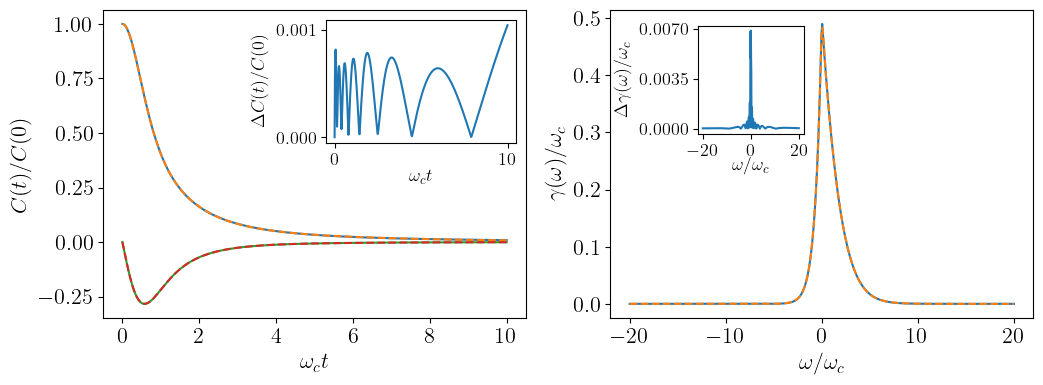

In [125]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Plots of fitted bcf and bath specturm
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['axes.titlesize'] = 15
mpl.rcParams['text.usetex'] = True

fig1, ax1 = plt.subplots(1,2, figsize=(12,4))

g = np.sqrt(-1j * (rkr + 1j*rki))
Lmb = np.diag(zkr - 1j*zki)

# Bath correlation function
# Real part 
ax1[0].plot(tlist, np.real(bcf) / c0)
ax1[0].plot(tlist, np.real(bcf_fit(tlist, g, Lmb)) / c0, linestyle='--')
# Imaginary part
ax1[0].plot(tlist, np.imag(bcf) / c0)
ax1[0].plot(tlist, np.imag(bcf_fit(tlist, g, Lmb)) / c0, linestyle='--')

ax1[0].set_xlabel(r'$\omega_c t$')
ax1[0].set_ylabel(r'$C(t)/C(0)$')

# Error - bcf
bcf_err = np.abs(bcf - bcf_fit(tlist, g, Lmb))

ax1_inset_left = inset_axes(ax1[0], width='45%', height='40%', loc='upper right')
ax1_inset_left.plot(tlist, bcf_err / c0)

ax1_inset_left.tick_params(labelsize=13)
ax1_inset_left.set_xticks([min(tlist), max(tlist)])
ax1_inset_left.set_yticks([0, np.round(np.max(bcf_err) / c0, 3)])
ax1_inset_left.set_ylabel(r'$\Delta C(t) / C(0)$', fontsize=13, labelpad=5)
ax1_inset_left.set_xlabel(r'$\omega_c t$', fontsize=13, labelpad=0)

# Spectrum
ax1[1].plot(omlist, bath.power_spectrum(omlist))
ax1[1].plot(omlist, ps_fit(omlist, g, Lmb), linestyle='--')

ax1[1].set_xlabel(r'$\omega/\omega_c$')
ax1[1].set_ylabel(r'$\gamma(\omega)/\omega_c$')

# Error - spectrum
spec_err = np.abs(bath.power_spectrum(omlist) - ps_fit(omlist, g, Lmb))

ax1_inset_right = inset_axes(ax1[1], width='25%', height='35%',
                             bbox_to_anchor=(-.52, -0.02, 1, 1),  # (x, y, width, height)
                             bbox_transform=ax1[1].transAxes)

ax1_inset_right.plot(omlist, spec_err)

ax1_inset_right.tick_params(labelsize=13)
ax1_inset_right.set_yticks([0, 0.5 * np.round(np.max(spec_err), 3), np.round(np.max(spec_err),3)])
ax1_inset_right.set_ylabel(r"$\Delta\gamma(\omega)/\omega_c$", fontsize=13, labelpad=5)
ax1_inset_right.set_xlabel(r'$\omega/\omega_c$', fontsize=13, labelpad=-2)

plt.show()

## Benchmarking of pseudomode master equation (PMME)

### PM parameters

Having correctly identified the parameters $\{\boldsymbol{g},\boldsymbol{\Lambda}\}$ of the fitted BCF 
\begin{equation*}
    C^E(t) = 
    \begin{cases}
    \boldsymbol{g}^Te^{-i\boldsymbol{\Lambda}t}\boldsymbol{g} & t\geq0,\\
    \boldsymbol{g}^Te^{i\boldsymbol{\Lambda}^*|t|}\boldsymbol{g} & t<0,
    \end{cases}
\end{equation*}
we now apply the gauge transformation $\boldsymbol{g'}=\boldsymbol{U}\boldsymbol{g}$, $\boldsymbol{Z}=\boldsymbol{U}\boldsymbol{\Lambda}\boldsymbol{U}^T$ to extract the corresponding PM parameters $\{\boldsymbol{g'},\boldsymbol{Z}\}$. 

In [126]:
from pseudomodes.fitting import pm_parameters

# Define r, z
r = rkr + 1j * rki
z = zkr - 1j * zki

gp, xi, gm, pm_params = pm_parameters(rk=r, zk=z, info=True)
print(pm_params['all'])

g = 
 [-0.03433 -0.31717 -0.28185  0.03176]

xi = 
 [[ 1.52796 -6.11842  0.2775   0.27758]
 [-6.11842  0.86383  0.46894 -0.07853]
 [ 0.2775   0.46894  1.30837 -0.17987]
 [ 0.27758 -0.07853 -0.17987 -0.00992]]

gm = 
 [17.4554  -7.45008  9.22298  0.79295]


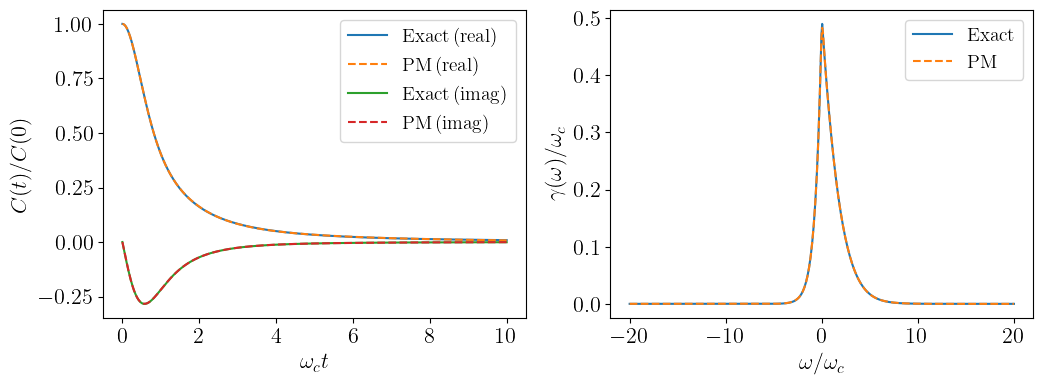

In [127]:
# Plot free PM correlation function and ps derived from C^E(t) = g'^T * exp(-i*Z*t) * g'
Z = xi - 0.5j*gm

# Plot BCF and spectrum using gp, Z parameterization.
fig2, ax2 = plt.subplots(1, 2, figsize=(12,4)) 

# BCF
ax2[0].plot(tlist, np.real(bcf) / c0, label=r"$\mathrm{Exact \, (real)}$") 
ax2[0].plot(tlist, np.real(bcf_fit(tlist, gp, Z)) / c0, linestyle='--', label=r"$\mathrm{PM \, (real)}$")

ax2[0].set_xlabel(r"$\omega_c t$")
ax2[0].set_ylabel(r"$C(t) / C(0)$")
ax2[0].legend()

ax2[0].plot(tlist, np.imag(bcf) / c0, label=r"$\mathrm{Exact \, (imag)}$") 
ax2[0].plot(tlist, np.imag(bcf_fit(tlist, gp, Z)) / c0, linestyle='--', label=r"$\mathrm{PM \, (imag)}$") 

ax2[0].set_xlabel(r"$\omega_c t$")
ax2[0].set_ylabel(r"$C(t) / C(0)$")
ax2[0].legend()

# Spectrum
ax2[1].plot(omlist, bath.power_spectrum(omlist), label=r"$\mathrm{Exact}$")
ax2[1].plot(omlist, ps_fit(omlist, gp, Z), linestyle='--', label=r"$\mathrm{PM}$")

ax2[1].set_xlabel(r"$\omega / \omega_c$")
ax2[1].set_ylabel(r"$\gamma(\omega) / \omega_c$")
ax2[1].legend()

plt.show()

### PMME and TEMPO

We now compare the simulation results of the PMME and TEMPO for the reduced system dynamics. 

NB: making the local PM dimensions too large seems to introduce numerical instabilites into the dynamics.

In [ ]:
from pseudomodes.spin_boson import pm_liouvillian

# Construct PMME
times = np.linspace(0, 25, 250)

# Local PM dims
N1, N2, N3, N4 = 4, 4, 3, 3
pm_dims = [N1, N2, N3, N4]

b_ops = []
for n in range(len(pm_dims)): 
    b_ops.append(qt.tensor([qt.identity(2)] + [qt.destroy(N) if n == idx else qt.identity(N) for idx, N in enumerate(pm_dims)]))

# Initial system + PM state
state_sys_pm = qt.tensor([qt.ket2dm(qt.basis(2))] + [qt.fock_dm(n) for n in pm_dims])

# Liouvillian
eps, Del = 1.0, 0.5
H_sys = 0.5 * eps * qt.sigmaz() + 0.5 * Del * qt.sigmax()
coup_sys = qt.sigmax()
L = pm_liouvillian(H_sys=H_sys, coup_op=coup_sys, coup_sys_pm=gp, pm_params=Z, pm_dims=pm_dims)

e_ops1 = qt.tensor([qt.sigmaz()] + [qt.identity(n) for n in pm_dims])
e_ops2 = qt.tensor([qt.sigmax()] + [qt.identity(n) for n in pm_dims])

In [129]:
result_pm = qt.mesolve(L, state_sys_pm, times, e_ops=[e_ops1, e_ops2] + [op.dag() * op for op in b_ops], options={'progress_bar': True})

10.0%. Run time:   1.03s. Est. time left: 00:00:00:09
20.1%. Run time:   2.29s. Est. time left: 00:00:00:09
30.1%. Run time:   3.54s. Est. time left: 00:00:00:08
40.2%. Run time:   4.78s. Est. time left: 00:00:00:07
50.2%. Run time:   6.09s. Est. time left: 00:00:00:06
60.2%. Run time:   7.44s. Est. time left: 00:00:00:04
70.3%. Run time:   8.85s. Est. time left: 00:00:00:03
80.3%. Run time:  10.15s. Est. time left: 00:00:00:02
90.4%. Run time:  11.72s. Est. time left: 00:00:00:01
100.0%. Run time:  13.08s. Est. time left: 00:00:00:00
Total run time:  13.09s


Text(0, 0.5, '$\\langle b^{\\dagger}_ib_i\\rangle$')

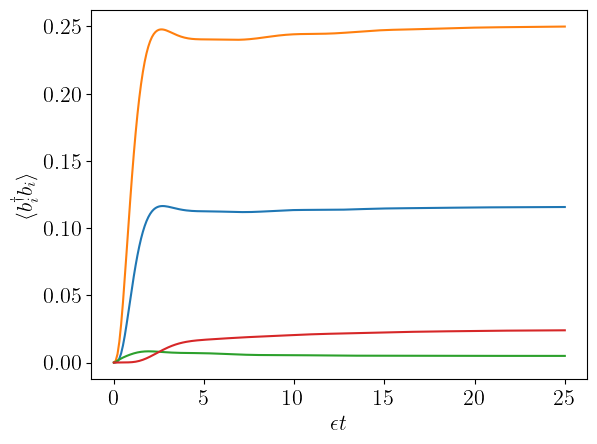

In [130]:
# Plot PM populations
fig3, ax3 = plt.subplots()

ax3.plot(times, result_pm.expect[2])
ax3.plot(times, result_pm.expect[3])
ax3.plot(times, result_pm.expect[4])
ax3.plot(times, result_pm.expect[5])

ax3.set_xlabel(r'$\epsilon t$')
ax3.set_ylabel(r'$\langle b^{\dagger}_ib_i\rangle$')

In [131]:
# TEMPO 
times = np.linspace(0, 25, 250)
dkmax = 70
dt = times[1] - times[0]
epsrel = 1e-6
eps, Del = 1.0, 0.5

state_sys = oq.operators.spin_dm('z+')
sigx = oq.operators.sigma('x')
sigz = oq.operators.sigma('z')

# Initialize process tensor
sys = oq.System(0.5 * eps * sigz + 0.5 * Del * sigx)

# J(omega) = sum_k|g_k|^2 delta(om - om_k) = 2 * alph * exp(-om/om_c)
bcf_tempo = oq.PowerLawSD(0.5 * alph / np.pi, zeta=1, cutoff=w_cut, cutoff_type='exponential', temperature=T)
bath_tempo = oq.Bath(sigx, bcf_tempo)
params_tempo = oq.TempoParameters(dt=dt, dkmax=dkmax, epsrel=epsrel)

In [132]:
result_tempo = oq.Tempo(system=sys, bath=bath_tempo, initial_state=state_sys, start_time=times[0], parameters=params_tempo)

dynamics = result_tempo.compute(end_time=times[-1])

_, sigx_exp = dynamics.expectations(sigx, real=True)
_, sigz_exp = dynamics.expectations(sigz, real=True)

--> TEMPO computation:
100.0%  249 of  249 [########################################] 00:01:24
Elapsed time: 84.2s


The absolute error between the PMME and TEMPO results (Bloch vector components) is given by 
\begin{equation*}
    |\Delta\langle\sigma_i(t)\rangle| = \langle\sigma_i(t)\rangle - {\rm Tr}[(\sigma_i\otimes\mathbb{I}_E)e^{\mathcal{L}t}[\rho_S(0)\otimes\rho_E]], \qquad i\in\{x,y,z\},
\end{equation*}
where $\langle\sigma_i(t)\rangle = {\rm Tr}[(\sigma_i\otimes\mathbb{I}_B)\rho_{SB}(t)]$.

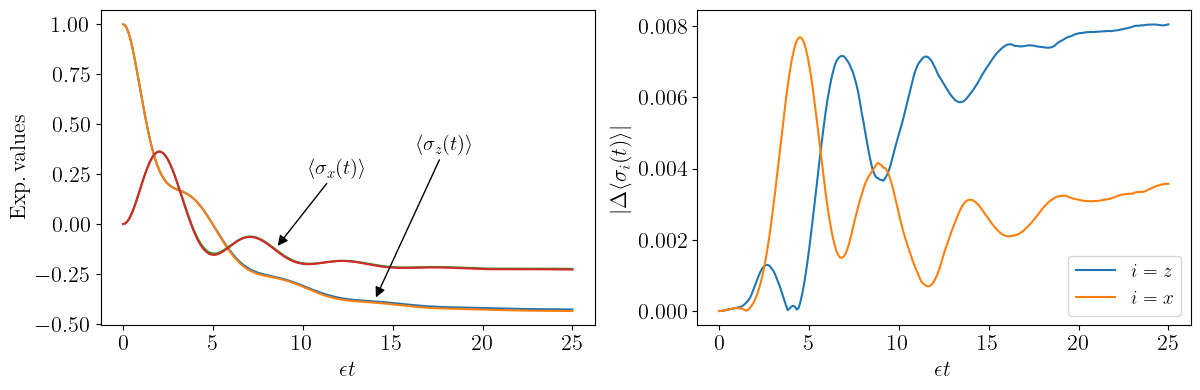

In [ ]:
# Plots of PMME and TEMPO results for sys exp values
fig4, ax4 = plt.subplots(1, 2, figsize=(12,4))

ax4[0].plot(times, sigz_exp)
ax4[0].plot(times, result_pm.expect[0])
ax4[0].plot(times, sigx_exp)
ax4[0].plot(times, result_pm.expect[1])

ax4[0].set_xlabel(r'$\epsilon t$')
ax4[0].set_ylabel(r'$\mathrm{Exp. \, values}$')

# <sigz> label
ax4[0].annotate(
    text=r'$\langle\sigma_z(t)\rangle$',
    xy=(14, -0.38),
    xytext=(18, 0.4),
    va="center",
    ha="center",
    arrowprops={'arrowstyle': '-|>', 'ec': 'k', 'fc': 'k'},
    fontsize=15
)

# <sigx> label
ax4[0].annotate(
    text=r'$\langle\sigma_x(t)\rangle$',
    xy=(8.5, -0.12),
    xytext=(12, 0.28),
    va="center",
    ha="center",
    arrowprops={'arrowstyle': '-|>', 'ec': 'k', 'fc': 'k'},
    fontsize=15
)

# Absolute error
rel_error_z = np.abs(result_pm.expect[0] - sigz_exp) 
rel_error_x = np.abs(result_pm.expect[1] - sigx_exp)

ax4[1].plot(times, rel_error_z, label=r'$i=z$')
ax4[1].plot(times, rel_error_x, label=r'$i=x$')

ax4[1].set_xlabel(r'$\epsilon t$')
ax4[1].set_ylabel(r'$|\Delta\langle\sigma_i(t)\rangle|$')
ax4[1].legend()

fig4.tight_layout()
plt.show()

Hence, we find a steady-state error of roughly 2% for the x- and z-Bloch vector components of $\rho_S(t)$, respectively. 

## Two-time correlation functions and heat exchange

The two-time correlation function $\langle\sigma_z(t_1)\sigma_z(t_2)\rangle$ can be evaluated exactly in the PM approach via the quantum regression theorem [ref]
\begin{equation*}
    \langle\sigma_z(t_1)\sigma_z(t_2)\rangle_{SE} = \theta(t_1-t_2)\,{\rm Tr}\Big\{\sigma_ze^{\mathcal{L}(t_1-t_2)}\big[\sigma_ze^{\mathcal{L}t_2}[\rho_{SE}(0)\big]\Big\} + \theta(t_2-t_1)\,{\rm Tr}\Big\{\sigma_ze^{\mathcal{L}(t_2-t_1)}\big[e^{\mathcal{L}t_1}[\rho_{SE}(0)]\sigma_z\big]\Big\},
\end{equation*}
where $\theta(t)$ is the Heaviside step function. Note that the quantities ($t_1>t_2$)
\begin{align*} 
    C^{>}_{zz}(t_1,t_2) &= \langle\sigma_z(t_1)\sigma_z(t_2)\rangle_{SE} = {\rm Tr}\Big\{\sigma_ze^{\mathcal{L}(t_1-t_2)}\big[\sigma_ze^{\mathcal{L}t_2}[\rho_{SE}(0)\big]\Big\}, \\
    C^{<}_{zz}(t_1,t_2) &= \langle\sigma_z(t_2)\sigma_z(t_1)\rangle_{SE} = {\rm Tr}\Big\{\sigma_ze^{\mathcal{L}(t_1-t_2)}\big[e^{\mathcal{L}t_2}[\rho_{SE}(0)]\sigma_z\big]\Big\},
\end{align*}
define what are known as greater and lesser correlation (or Green's) functions. 

Since $\langle\sigma_z(t_1)\sigma_z(t_2)\rangle$ is Hermitian, these projections are connected via the following relation
\begin{equation*}
    C^{<}_{zz}(t_1,t_2) = C^{>*}_{zz}(t_1,t_2), \qquad t_1\geq t_2,
\end{equation*}
such that it suffices to compute $C^>_{zz}(t_1,t_2)$. 

In [135]:
# TTCF solver
solver = qt.MESolver(L, options={'progress_bar': True}) 

# Evaluates 3TCF of form <A(t)B(t+tau)C(t)>
# Time ordered (t>t')
ttcf_pm_gtr_raw = qt.correlation_3op(solver=solver, 
                                     state0=state_sys_pm,
                                     tlist=times,
                                     taulist=times,
                                     A=None,
                                     B=e_ops1,
                                     C=e_ops1)

# Transform axes
# (t>t')
ttcf_pm_gtr = np.zeros([len(times),len(times)],dtype=complex)
for k1 in range(len(times)):
    for k2 in range(1,k1+1):
        ttcf_pm_gtr[k2][k1] += ttcf_pm_gtr_raw[k2][k1-k2]

# Full TTCF (t>t' & t<t')
# ttcf_pm_gtr = np.load('data/ohmic/ohmic_ttcf_pm_gtr_beta_1.0_alph_0.25.npy')
ttcf_pm = np.zeros([len(times),len(times)],dtype=complex)
ttcf_pm += ttcf_pm_gtr
for k1 in range(len(times)):
    for k2 in range(len(times)):
        if k1>k2:
            ttcf_pm[k1][k2] = np.conj(ttcf_pm_gtr[k2][k1])

10.4%. Run time: 309.66s. Est. time left: 00:00:44:39
20.3%. Run time: 632.57s. Est. time left: 00:00:41:20
30.3%. Run time: 962.99s. Est. time left: 00:00:36:57
40.2%. Run time: 1291.25s. Est. time left: 00:00:31:57
50.2%. Run time: 1614.22s. Est. time left: 00:00:26:41
60.2%. Run time: 1932.47s. Est. time left: 00:00:21:19
70.1%. Run time: 2234.10s. Est. time left: 00:00:15:52
80.1%. Run time: 2536.09s. Est. time left: 00:00:10:30
90.0%. Run time: 2858.34s. Est. time left: 00:00:05:16
100.0%. Run time: 3164.06s. Est. time left: 00:00:00:00
Total run time: 3164.06s


In [173]:
ttcf_pm_gtr = np.zeros([len(times),len(times)],dtype=complex)
for k1 in range(len(times)):
    for k2 in range(k1+1):
        ttcf_pm_gtr[k2][k1] += ttcf_pm_gtr_raw[k2][k1-k2]

ttcf_pm = np.zeros([len(times),len(times)],dtype=complex)
ttcf_pm += ttcf_pm_gtr
for k1 in range(len(times)):
    for k2 in range(len(times)):
        if k1>k2:
            ttcf_pm[k1][k2] = np.conj(ttcf_pm_gtr[k2][k1])

In [ ]:
# CHECK 
# Load data
ttcf_pm_gtr = np.load(f'data/ohmic/ohmic_ttcf_pm_gtr_beta_1.0_alph_0.25.npy')

ttcf_pm_less = np.zeros([len(times),len(times)],dtype=complex)
for k1 in range(len(times)):
    for k2 in range(len(times)):
            if k1>=k2:
                 ttcf_pm_less[k1][k2] = np.conj(ttcf_pm_gtr[k2][k1])
            elif k1<k2:
                 ttcf_pm_less[k1][k2] = np.NaN + np.NaN*1j

#np.save('data/ohmic/ohmic_ttcf_pm_less_beta_' + str(1./T) + '_alph_' + str(alph) + '.npy', ttcf_pm_less)

In [184]:
pt = oq.pt_tempo_compute(bath=bath_tempo,
                         start_time=times[0],
                         end_time=times[-1],
                         parameters=params_tempo)

--> PT-TEMPO computation:
100.0%  249 of  249 [########################################] 00:03:48
Elapsed time: 228.3s


In [ ]:
# Define process tensor 
pt = oq.pt_tempo_compute(bath=bath_tempo,
                         start_time=times[0],
                         end_time=times[-1],
                         parameters=params_tempo)

# TTCF solver
# Time ordered (t>t')
_, ttcf_gtr = oq.compute_correlations(system=sys,
                                      process_tensor=pt,
                                      operator_a=sigz,
                                      operator_b=sigz,
                                      times_a=(times[0], times[-1]),
                                      times_b=(times[0], times[-1]),
                                      time_order='ordered',
                                      initial_state=state_sys,
                                      dt=dt,
                                      progress_type='bar')

# Full TTCF (t>t' & t<t')
# ttcf_gtr = np.load('data/ohmic/ohmic_ttcf_tempo_gtr_beta_1.0_alph_0.25.npy')
ttcf = np.zeros([len(times),len(times)],dtype=complex)
ttcf += ttcf_gtr
for k1 in range(len(times)):
    for k2 in range(len(times)):
        if k1>k2:
            ttcf[k1][k2] = np.conj(ttcf_gtr[k2][k1])

--> PT-TEMPO computation:
100.0%  249 of  249 [########################################] 00:04:05
Elapsed time: 245.3s
--> Compute correlations:
100.0%  250 of  250 [########################################] 00:38:22
Elapsed time: 2302.2s


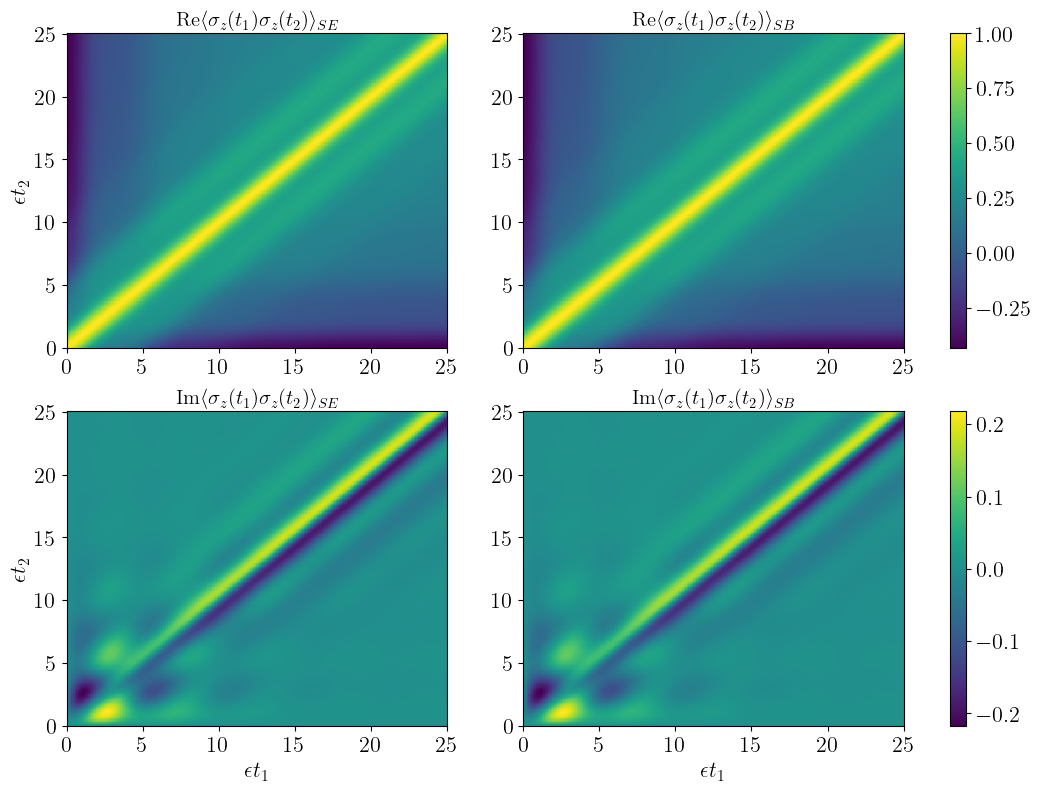

In [175]:
# Plot real and imaginary parts of TTCF
fig5, ax5 = plt.subplots(2, 2, figsize=(12,9))

T1, T2 = np.meshgrid(times, times)

data_real = [np.real(ttcf_pm), np.real(ttcf)]
data_imag = [np.imag(ttcf_pm), np.imag(ttcf)]

# Extract global max/min of real and imaginary parts 
global_min_real = min([np.min(np.real(ttcf)), np.min(np.real(ttcf_pm))])
global_min_imag = min([np.min(np.imag(ttcf)), np.min(np.imag(ttcf_pm))])

global_max_real = max([np.max(np.real(ttcf)), np.max(np.real(ttcf_pm))])
global_max_imag = max([np.max(np.imag(ttcf)), np.max(np.imag(ttcf_pm))])

# Plot using pcolor
for i, ax in enumerate(ax5[0,:].flat):
    mesh_real = ax.pcolor(T1, T2, data_real[i], cmap='viridis', vmin=global_min_real, vmax=global_max_real, shading='auto')
for i, ax in enumerate(ax5[1,:].flat):
    mesh_imag = ax.pcolor(T1, T2, data_imag[i], cmap='viridis', vmin=global_min_imag, vmax=global_max_imag, shading='auto')

ax5[1][0].set_xlabel(r'$\epsilon t_1$')
ax5[0][0].set_ylabel(r'$\epsilon t_2$')
ax5[0][0].set_title(r'$\mathrm{Re}\langle \sigma_z(t_1)\sigma_z(t_2)\rangle_{SE}$')
ax5[0][1].set_title(r'$\mathrm{Re}\langle \sigma_z(t_1)\sigma_z(t_2)\rangle_{SB}$')

ax5[1][1].set_xlabel(r'$\epsilon t_1$')
ax5[1][0].set_ylabel(r'$\epsilon t_2$')
ax5[1][0].set_title(r'$\mathrm{Im}\langle \sigma_z(t_1)\sigma_z(t_2)\rangle_{SE}$')
ax5[1][1].set_title(r'$\mathrm{Im}\langle \sigma_z(t_1)\sigma_z(t_2)\rangle_{SB}$')

for ax in ax5.flat:
    ax.set_xlim([times[0], times[-1]])

# colorbar 
fig5.colorbar(mesh_real, ax=ax5[0,:], orientation='vertical', fraction=0.05, pad=0.05)
fig5.colorbar(mesh_imag, ax=ax5[1,:], orientation='vertical', fraction=0.05, pad=0.05)

plt.show()

Relative error:
\begin{equation*}
    \mathrm{Rel. \, Error} = 100 \times \frac{|\Delta\langle\sigma_z(t_1)\sigma_z(t_2)\rangle|}{|\langle\sigma_z(t_1)\sigma_z(t_2)\rangle|}
\end{equation*}
where $\Delta\langle\sigma_z(t_1)\sigma_z(t_2)\rangle = \langle\sigma_z(t_1)\sigma_z(t_2)\rangle_{SE} - \langle\sigma_z(t_1)\sigma_z(t_2)\rangle_{SB}$. 

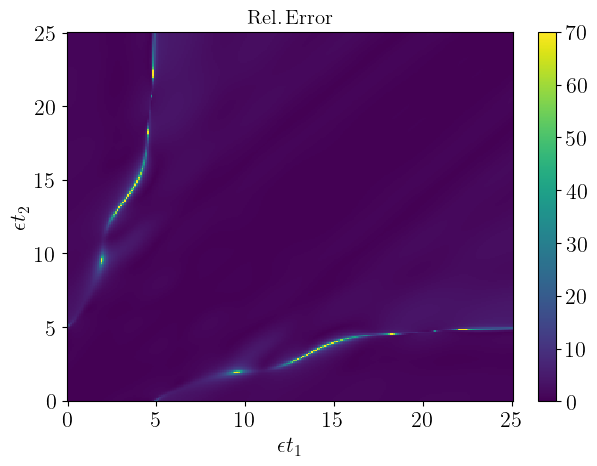

In [ ]:
# Relative error |<sigz(t_1)sigz(t_2)>_{SE} - <sigz(t_1)sigz(t_2)>_{SE}|:
ttcf_error = 100 * np.abs(ttcf_pm - ttcf) / np.abs(ttcf_pm)

plt.figure()

mesh = plt.pcolormesh(T1, T2, np.real(ttcf_error), cmap='viridis', vmin=0, vmax=70, shading='auto')

plt.colorbar(mesh, fraction=0.05, pad=0.05)
plt.xlabel(r'$\epsilon t_1$')
plt.ylabel(r'$\epsilon t_2$')
plt.title(r'$\mathrm{Rel. \, Error}$')
plt.show()

In [181]:
# Save data 
import json 

params_dict = {'temperature': T, 
               'cutoff': w_cut, 
               'coupling': alph, 
               'Energy splitting': eps, 
               'Bias': Del, 
               'Max. time': times[-1], 
               'Times_len': len(times)
               }

params_dict_pm = {'No. pseudomodes': len(pm_dims)}

for idx, n in enumerate(pm_dims):
    params_dict_pm.update({f'Local dim PM{idx+1}': n})

params_dict_tempo = {'dkmax': dkmax,
                     'time_step': dt,
                     'epsrel': epsrel}

## Save simulation data
# Expectation values
np.save('data/ohmic/ohmic_sigz_pm_beta_' + str(1./T) + '_alph_' + str(alph) + '.npy', result_pm.expect[0])
np.save('data/ohmic/ohmic_sigx_pm_beta_' + str(1./T) + '_alph_' + str(alph) + '.npy', result_pm.expect[1])
np.save('data/ohmic/ohmic_sigz_tempo_beta_' + str(1./T) + '_alph_' + str(alph) +  '.npy', sigz_exp)
np.save('data/ohmic/ohmic_sigx_tempo_beta_' + str(1./T) + '_alph_' + str(alph) +  '.npy', sigx_exp)

# TTCF
np.save('data/ohmic/ohmic_ttcf_pm_beta_' + str(1./T) + '_alph_' + str(alph) + '.npy', ttcf_pm)
np.save('data/ohmic/ohmic_ttcf_tempo_beta_' + str(1./T) + '_alph_' + str(alph) + '.npy', ttcf)
# # t > t'
# np.save('data/ohmic/ohmic_ttcf_pm_gtr_beta_' + str(1./T) + '_alph_' + str(alph) + '.npy', ttcf_pm_gtr)
# np.save('data/ohmic/ohmic_ttcf_tempo_gtr_beta_' + str(1./T) + '_alph_' + str(alph) + '.npy', ttcf_gtr)

# Save metadata
metadata = {
    'parameters': params_dict,
    'Pseudomode parameters': params_dict_pm,
    'TEMPO parameters': params_dict_tempo
}

with open ('data/ohmic/metadata_beta_' + str(1./T) + '_alph_' + str(alph) + '.json', 'w') as f:
    json.dump(metadata, f, indent=4)

### Heat statistics

<!--Notes ... output of TwoTimeBathCorrelations()... -->

In [ ]:
# Heat exchange PMs
# Use same method from Oqupy to extract heat statistics - use TTCF data as input
bath_pm = oq.bath_dynamics.TwoTimeBathCorrelations(system=sys,
                                                   bath=bath_tempo,
                                                   process_tensor=pt,
                                                   initial_state=state_sys,
                                                   system_correlations=ttcf_pm_gtr)

# Extract bath occupation 
freqs = np.linspace(0,8,150)
bath_energy_pm_array = np.zeros((len(freqs),len(times)))
for k1 in range(len(times)):
    for k2 in range(len(freqs)):
        if freqs[k2]!=0:
            # dw must satisfy dw^-1 >> t_relax 
            _ , occ = bath_pm.occupation(freqs[k2], dw=0.01*eps, change_only=True, progress_type='bar')
            bath_energy_pm_array[k2][k1] = freqs[k2]*occ[k1]

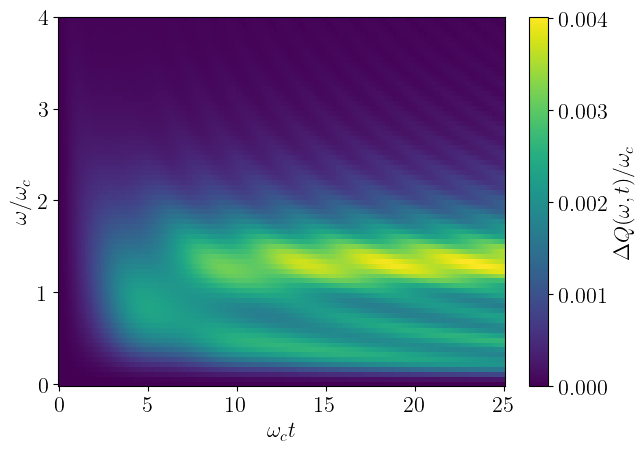

In [ ]:
# Plot PM spectrum
fig6, ax6 = plt.subplots()

W, T_spec = np.meshgrid(times, freqs)

mesh_spec_pm = ax6.pcolor(W, T_spec, bath_energy_pm_array, cmap='viridis', vmin=np.min(bath_energy_pm_array), vmax=np.max(bath_energy_pm_array), shading='nearest')

ax6.set_ylim(ymax=4.0)
ax6.set_xlabel(r'$\omega_c t$')
ax6.set_ylabel(r'$\omega/\omega_c$')
cbar = fig6.colorbar(mesh_spec_pm, ax=ax6, orientation='vertical', fraction=0.05, pad=0.05)
cbar.set_label(r'$\Delta Q(\omega,t)/\omega_c$')

In [240]:
# Heat exchange TEMPO
bath_tempo = oq.bath_dynamics.TwoTimeBathCorrelations(system=sys,
                                                      bath=bath_tempo,
                                                      process_tensor=pt,
                                                      initial_state=state_sys,
                                                      system_correlations=ttcf_gtr)

# Extract bath occupation 
freqs = np.linspace(0,8,150)
bath_energy_array = np.zeros((len(freqs),len(times)))
for k1 in range(len(times)):
    for k2 in range(len(freqs)):
        if freqs[k2]!=0:
            # dw must satisfy dw^-1 >> t_relax 
            _ , occ = bath_tempo.occupation(freqs[k2], dw=0.01*eps, change_only=True, progress_type='bar')
            bath_energy_array[k2][k1] = freqs[k2]*occ[k1]

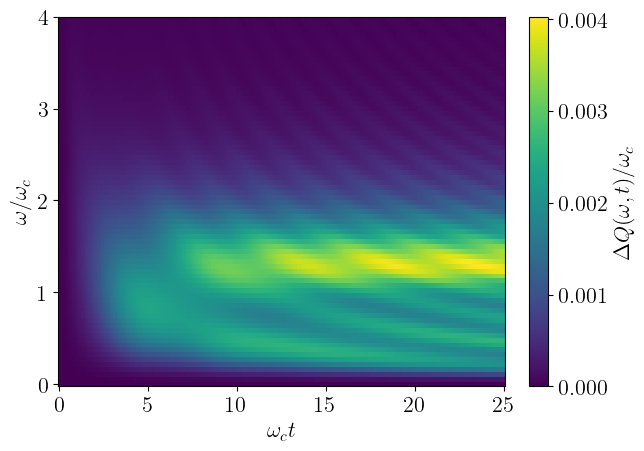

In [ ]:
# Plot TEMPO spectrum
fig7, ax7 = plt.subplots()

mesh_spec = ax7.pcolor(W, T_spec, bath_energy_array, cmap='viridis', vmin=np.min(bath_energy_array), vmax=np.max(bath_energy_array), shading='nearest')

ax7.set_ylim(ymax=4.0)
ax7.set_xlabel(r'$\omega_c t$')
ax7.set_ylabel(r'$\omega/\omega_c$')
cbar = fig7.colorbar(mesh_spec, ax=ax7, orientation='vertical', fraction=0.05, pad=0.05)
cbar.set_label(r'$\Delta Q(\omega,t)/\omega_c$')